In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/crimes-against-women-in-india-2001-2021/CrimesOnWomenData.csv
/kaggle/input/crimes-against-women-in-india-2001-2021/description.csv


In [2]:
import pandas as pd

# Load the datasets
crimes_data = pd.read_csv('/kaggle/input/crimes-against-women-in-india-2001-2021/CrimesOnWomenData.csv')
description_data = pd.read_csv('/kaggle/input/crimes-against-women-in-india-2001-2021/description.csv')

# Display the first few rows of each dataset to understand the structure
print("Crimes Data Head:")
print(crimes_data.head())

print("\nDescription Data Head:")
print(description_data.head())

# Display the basic information about the dataset
print("\nCrimes Data Info:")
print(crimes_data.info())

print("\nDescription Data Info:")
print(description_data.info())

# Check for missing values in the dataset
print("\nMissing Values in Crimes Data:")
print(crimes_data.isnull().sum())

print("\nMissing Values in Description Data:")
print(description_data.isnull().sum())

Crimes Data Head:
   Unnamed: 0              State  Year  Rape   K&A   DD   AoW   AoM    DV  WT
0           0     ANDHRA PRADESH  2001   871   765  420  3544  2271  5791   7
1           1  ARUNACHAL PRADESH  2001    33    55    0    78     3    11   0
2           2              ASSAM  2001   817  1070   59   850     4  1248   0
3           3              BIHAR  2001   888   518  859   562    21  1558  83
4           4       CHHATTISGARH  2001   959   171   70  1763   161   840   0

Description Data Head:
   Unnamed: 0 Column Names         Explanation
0           0        State               State
1           1         Year                Year
2           2         Rape   No. of Rape cases
3           3          K&A  Kidnap And Assault
4           4           DD        Dowry Deaths

Crimes Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0  

In [3]:
# Drop the unnecessary 'Unnamed: 0' column from both datasets
crimes_data_cleaned = crimes_data.drop(columns=['Unnamed: 0'])
description_data_cleaned = description_data.drop(columns=['Unnamed: 0'])

# Renaming columns in Crimes Data for better readability
crimes_data_cleaned.columns = ['State', 'Year', 'Rape', 'Kidnapping_Abduction', 'Dowry_Deaths', 
                               'Assault_on_Women', 'Assault_on_Men', 'Domestic_Violence', 
                               'Witchcraft']

# Display the cleaned dataset head
print("Cleaned Crimes Data Head:")
print(crimes_data_cleaned.head())

# Display the cleaned Description Data head
print("\nCleaned Description Data Head:")
print(description_data_cleaned.head())

Cleaned Crimes Data Head:
               State  Year  Rape  Kidnapping_Abduction  Dowry_Deaths  \
0     ANDHRA PRADESH  2001   871                   765           420   
1  ARUNACHAL PRADESH  2001    33                    55             0   
2              ASSAM  2001   817                  1070            59   
3              BIHAR  2001   888                   518           859   
4       CHHATTISGARH  2001   959                   171            70   

   Assault_on_Women  Assault_on_Men  Domestic_Violence  Witchcraft  
0              3544            2271               5791           7  
1                78               3                 11           0  
2               850               4               1248           0  
3               562              21               1558          83  
4              1763             161                840           0  

Cleaned Description Data Head:
  Column Names         Explanation
0        State               State
1         Year           

Summary Statistics:
              Year         Rape  Kidnapping_Abduction  Dowry_Deaths  \
count   736.000000   736.000000            736.000000    736.000000   
mean   2011.149457   727.855978           1134.542120    215.692935   
std       6.053453   977.024945           1993.536828    424.927334   
min    2001.000000     0.000000              0.000000      0.000000   
25%    2006.000000    35.000000             24.750000      1.000000   
50%    2011.000000   348.500000            290.000000     29.000000   
75%    2016.000000  1069.000000           1216.000000    259.000000   
max    2021.000000  6337.000000          15381.000000   2524.000000   

       Assault_on_Women  Assault_on_Men  Domestic_Violence  Witchcraft  
count        736.000000      736.000000         736.000000  736.000000  
mean        1579.115489      332.722826        2595.078804   28.744565  
std         2463.962518      806.024551        4042.004953   79.999660  
min            0.000000        0.000000         

/tmp/ipykernel_17/943414446.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='Year', y='Rape', data=crimes_data_cleaned, marker='o', ci=None)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


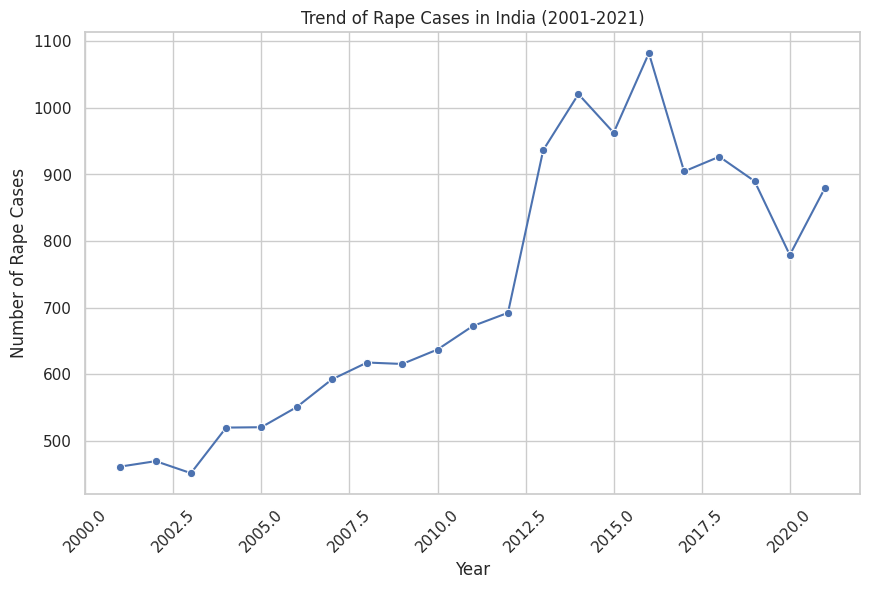

/tmp/ipykernel_17/943414446.py:24: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='Year', y='Kidnapping_Abduction', data=crimes_data_cleaned, marker='o', ci=None)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


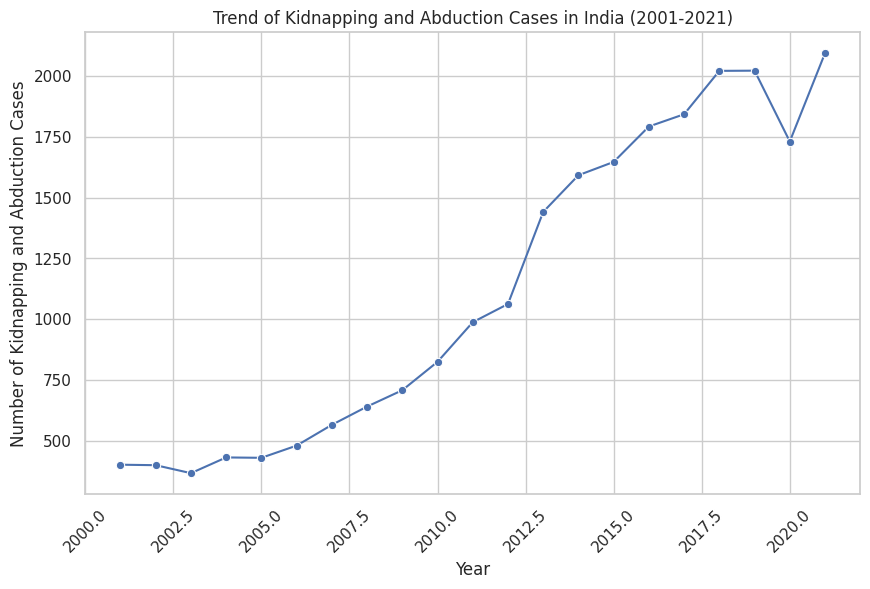

In [4]:
# Generate summary statistics for each crime type
summary_stats = crimes_data_cleaned.describe()
print("Summary Statistics:")
print(summary_stats)

# Univariate Analysis: Plotting the distribution of Rape cases over the years
import matplotlib.pyplot as plt
import seaborn as sns

# Set the plot style
sns.set(style="whitegrid")

# Plotting Rape cases over the years
plt.figure(figsize=(10, 6))
sns.lineplot(x='Year', y='Rape', data=crimes_data_cleaned, marker='o', ci=None)
plt.title('Trend of Rape Cases in India (2001-2021)')
plt.xlabel('Year')
plt.ylabel('Number of Rape Cases')
plt.xticks(rotation=45)
plt.show()

# Univariate Analysis: Plotting the distribution of Kidnapping and Abduction cases over the years
plt.figure(figsize=(10, 6))
sns.lineplot(x='Year', y='Kidnapping_Abduction', data=crimes_data_cleaned, marker='o', ci=None)
plt.title('Trend of Kidnapping and Abduction Cases in India (2001-2021)')
plt.xlabel('Year')
plt.ylabel('Number of Kidnapping and Abduction Cases')
plt.xticks(rotation=45)
plt.show()

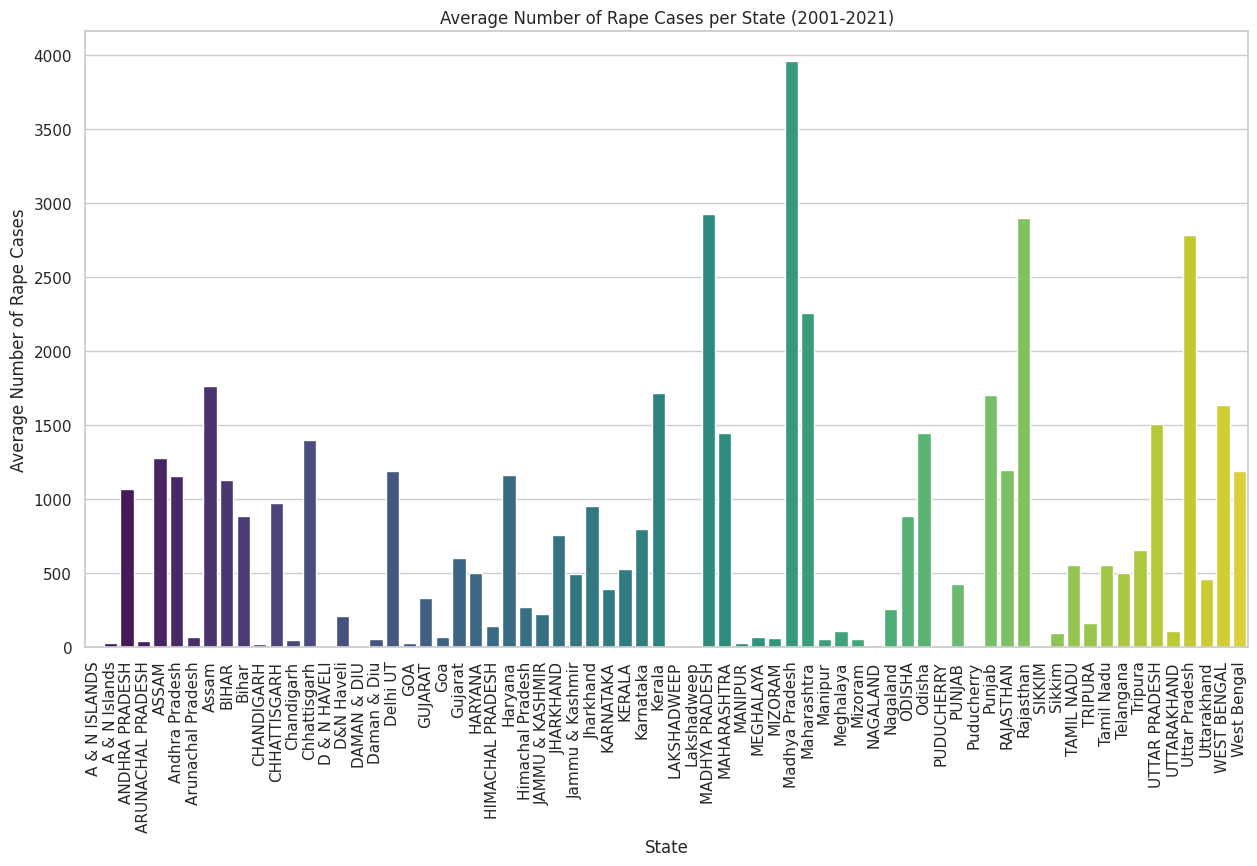

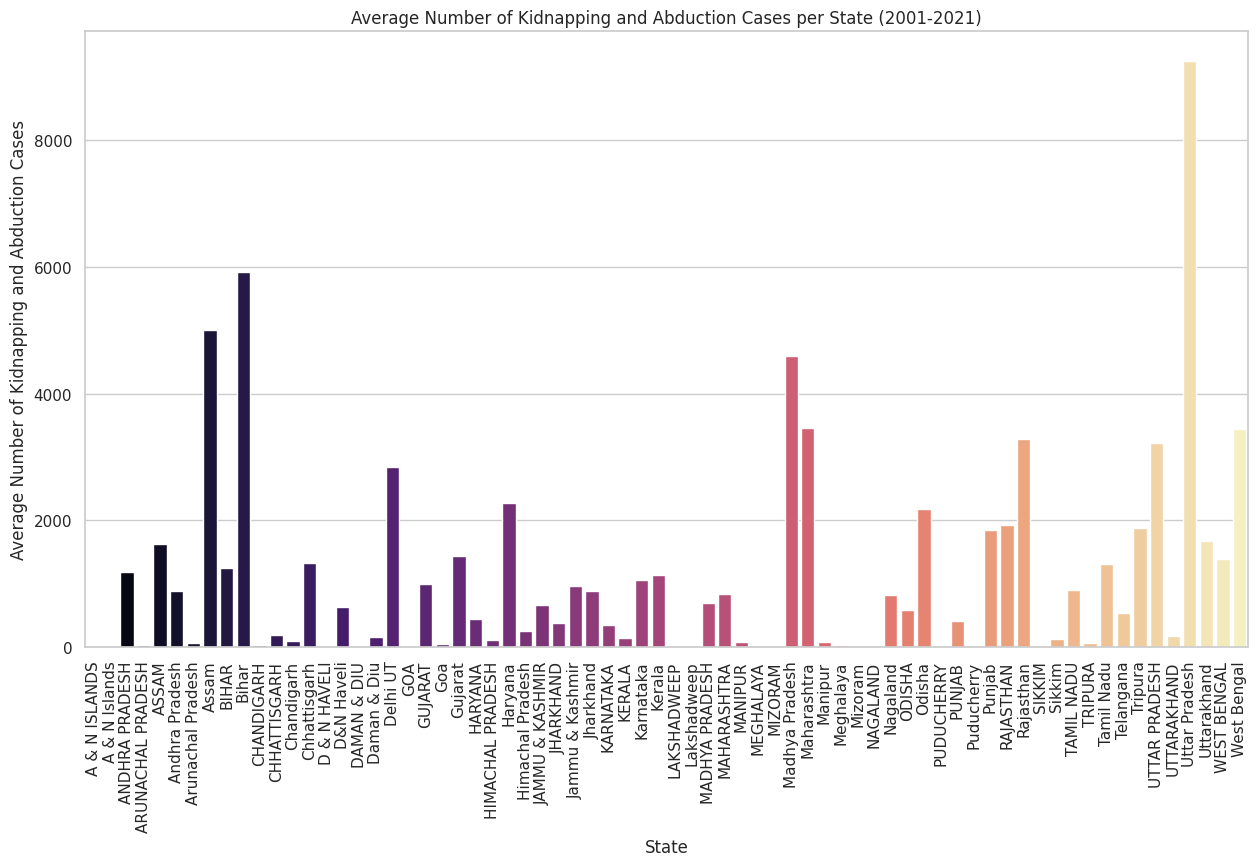

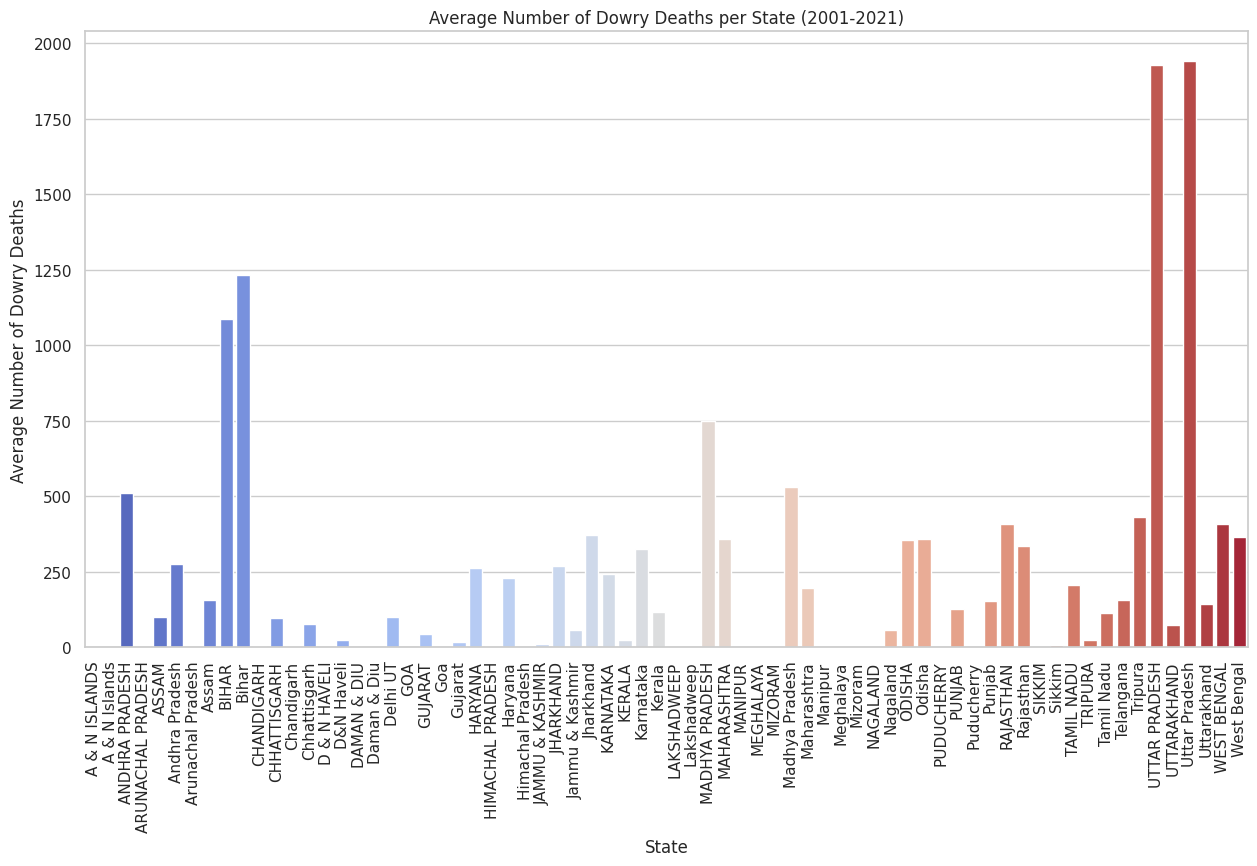

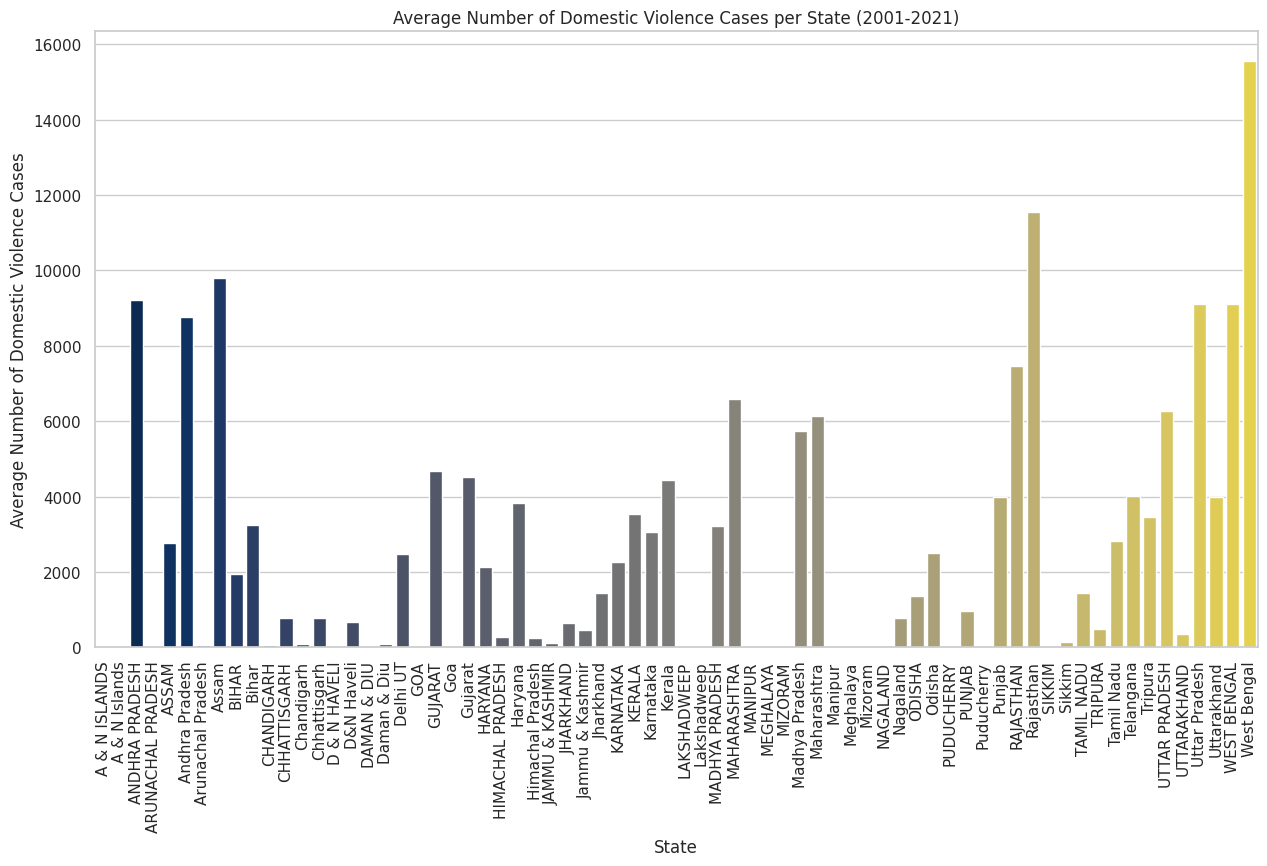

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grouping the data by State and calculating the mean of each crime type
state_wise_crime = crimes_data_cleaned.groupby('State').mean()

# Plotting the average Rape cases per state
plt.figure(figsize=(15, 8))
sns.barplot(x=state_wise_crime.index, y='Rape', data=state_wise_crime, palette='viridis')
plt.title('Average Number of Rape Cases per State (2001-2021)')
plt.xlabel('State')
plt.ylabel('Average Number of Rape Cases')
plt.xticks(rotation=90)
plt.show()

# Plotting the average Kidnapping and Abduction cases per state
plt.figure(figsize=(15, 8))
sns.barplot(x=state_wise_crime.index, y='Kidnapping_Abduction', data=state_wise_crime, palette='magma')
plt.title('Average Number of Kidnapping and Abduction Cases per State (2001-2021)')
plt.xlabel('State')
plt.ylabel('Average Number of Kidnapping and Abduction Cases')
plt.xticks(rotation=90)
plt.show()

# Plotting the average Dowry Deaths per state
plt.figure(figsize=(15, 8))
sns.barplot(x=state_wise_crime.index, y='Dowry_Deaths', data=state_wise_crime, palette='coolwarm')
plt.title('Average Number of Dowry Deaths per State (2001-2021)')
plt.xlabel('State')
plt.ylabel('Average Number of Dowry Deaths')
plt.xticks(rotation=90)
plt.show()

# Plotting the average Domestic Violence cases per state
plt.figure(figsize=(15, 8))
sns.barplot(x=state_wise_crime.index, y='Domestic_Violence', data=state_wise_crime, palette='cividis')
plt.title('Average Number of Domestic Violence Cases per State (2001-2021)')
plt.xlabel('State')
plt.ylabel('Average Number of Domestic Violence Cases')
plt.xticks(rotation=90)
plt.show()

/tmp/ipykernel_17/655346263.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x=yearly_crime_trends.index, y='Rape', data=yearly_crime_trends, marker='o', ci=None)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


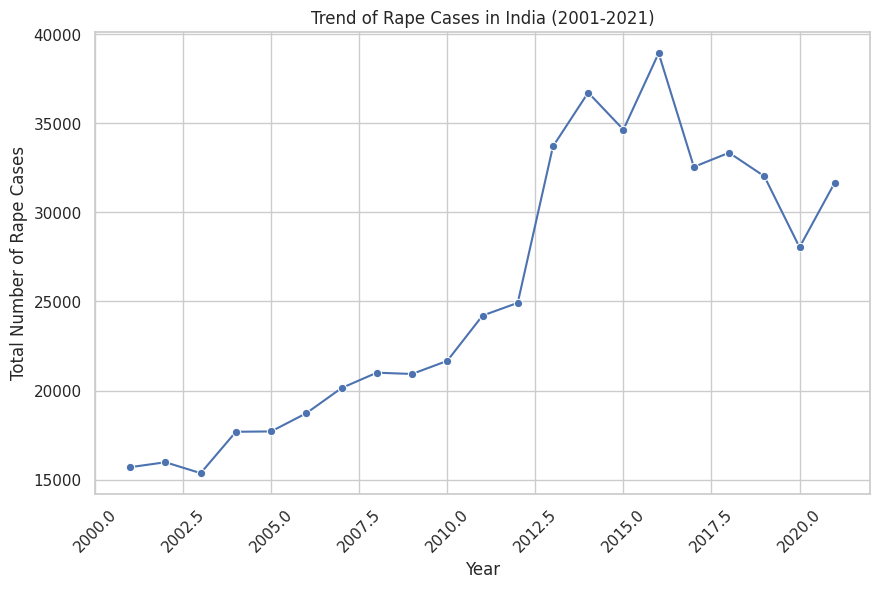

/tmp/ipykernel_17/655346263.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x=yearly_crime_trends.index, y='Kidnapping_Abduction', data=yearly_crime_trends, marker='o', ci=None)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


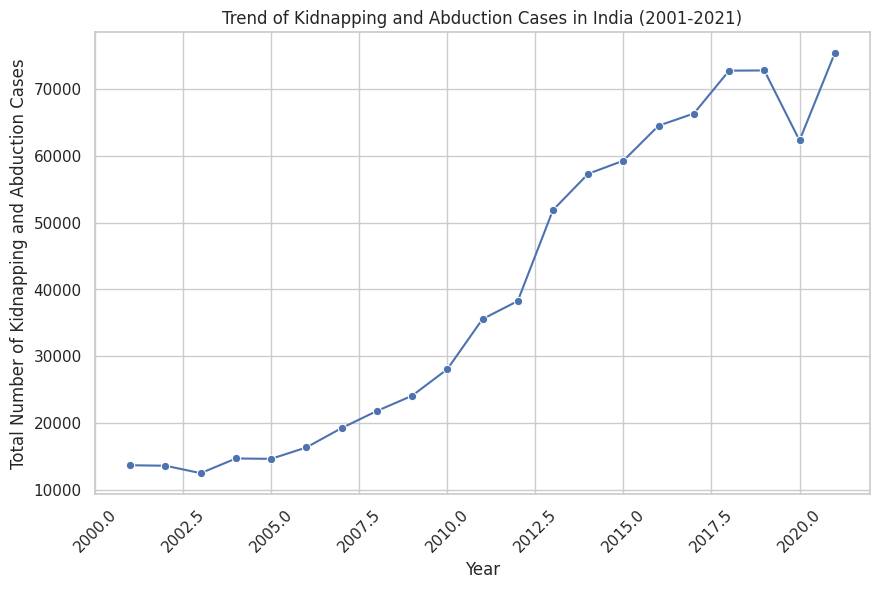

/tmp/ipykernel_17/655346263.py:24: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x=yearly_crime_trends.index, y='Dowry_Deaths', data=yearly_crime_trends, marker='o', ci=None)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


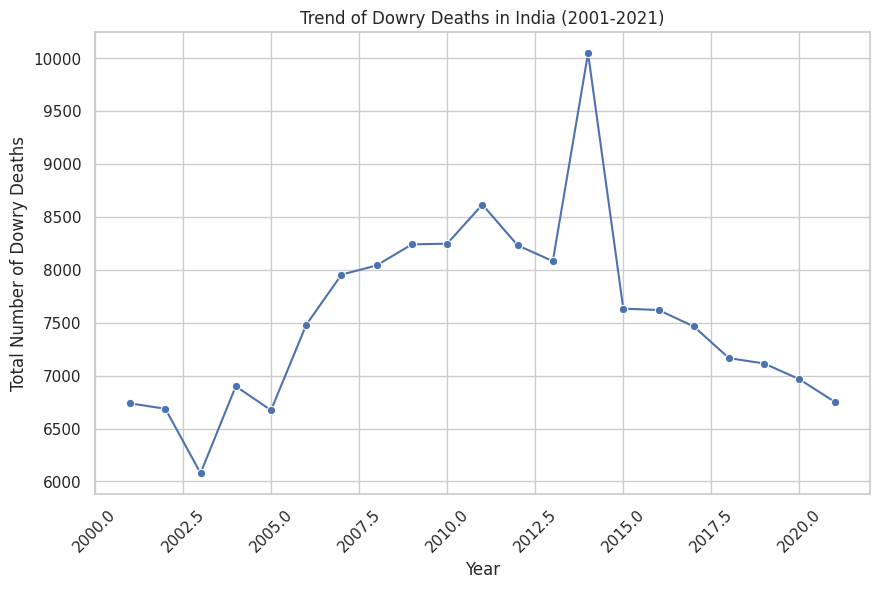

/tmp/ipykernel_17/655346263.py:33: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x=yearly_crime_trends.index, y='Domestic_Violence', data=yearly_crime_trends, marker='o', ci=None)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


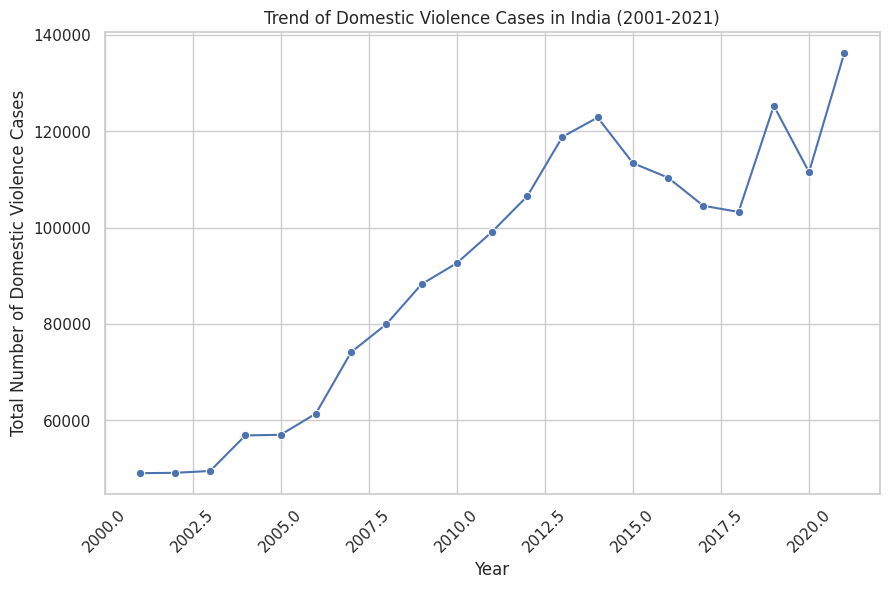

In [6]:
# Grouping the data by Year and calculating the sum of each crime type
yearly_crime_trends = crimes_data_cleaned.groupby('Year').sum()

# Plotting the trend of Rape cases over the years
plt.figure(figsize=(10, 6))
sns.lineplot(x=yearly_crime_trends.index, y='Rape', data=yearly_crime_trends, marker='o', ci=None)
plt.title('Trend of Rape Cases in India (2001-2021)')
plt.xlabel('Year')
plt.ylabel('Total Number of Rape Cases')
plt.xticks(rotation=45)
plt.show()

# Plotting the trend of Kidnapping and Abduction cases over the years
plt.figure(figsize=(10, 6))
sns.lineplot(x=yearly_crime_trends.index, y='Kidnapping_Abduction', data=yearly_crime_trends, marker='o', ci=None)
plt.title('Trend of Kidnapping and Abduction Cases in India (2001-2021)')
plt.xlabel('Year')
plt.ylabel('Total Number of Kidnapping and Abduction Cases')
plt.xticks(rotation=45)
plt.show()

# Plotting the trend of Dowry Deaths over the years
plt.figure(figsize=(10, 6))
sns.lineplot(x=yearly_crime_trends.index, y='Dowry_Deaths', data=yearly_crime_trends, marker='o', ci=None)
plt.title('Trend of Dowry Deaths in India (2001-2021)')
plt.xlabel('Year')
plt.ylabel('Total Number of Dowry Deaths')
plt.xticks(rotation=45)
plt.show()

# Plotting the trend of Domestic Violence cases over the years
plt.figure(figsize=(10, 6))
sns.lineplot(x=yearly_crime_trends.index, y='Domestic_Violence', data=yearly_crime_trends, marker='o', ci=None)
plt.title('Trend of Domestic Violence Cases in India (2001-2021)')
plt.xlabel('Year')
plt.ylabel('Total Number of Domestic Violence Cases')
plt.xticks(rotation=45)
plt.show()

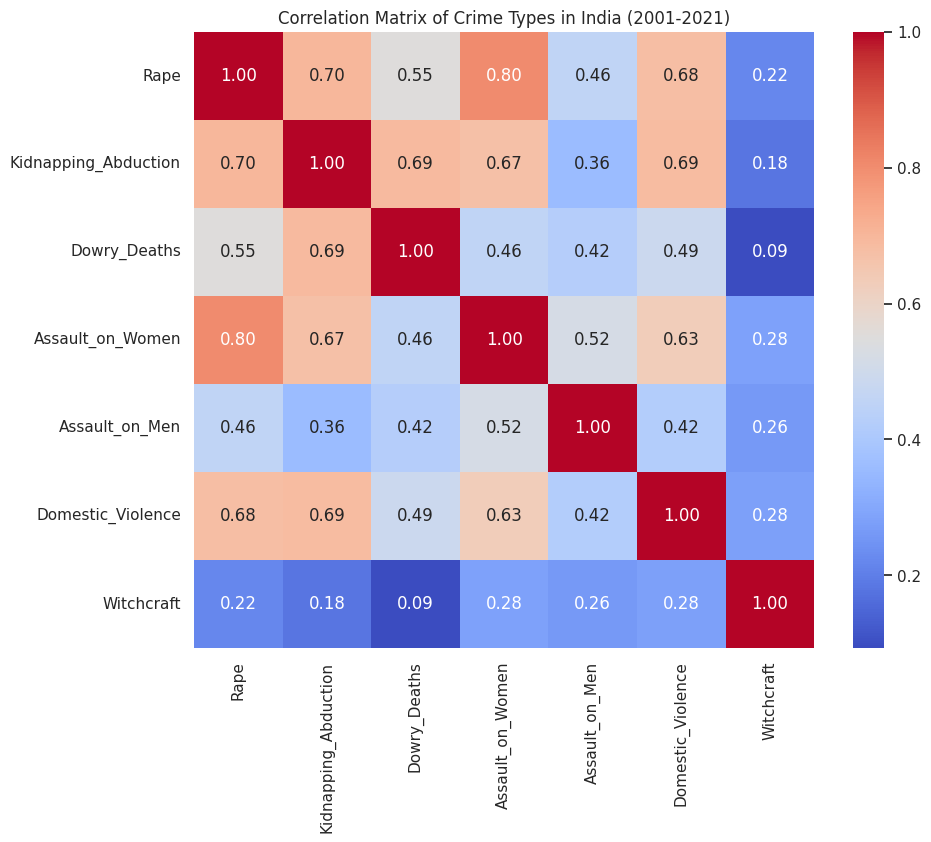

In [7]:
# Exclude the 'Year' and 'State' columns from the correlation calculation
correlation_matrix = crimes_data_cleaned.drop(columns=['Year', 'State']).corr()

# Plotting the correlation heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Crime Types in India (2001-2021)')
plt.show()

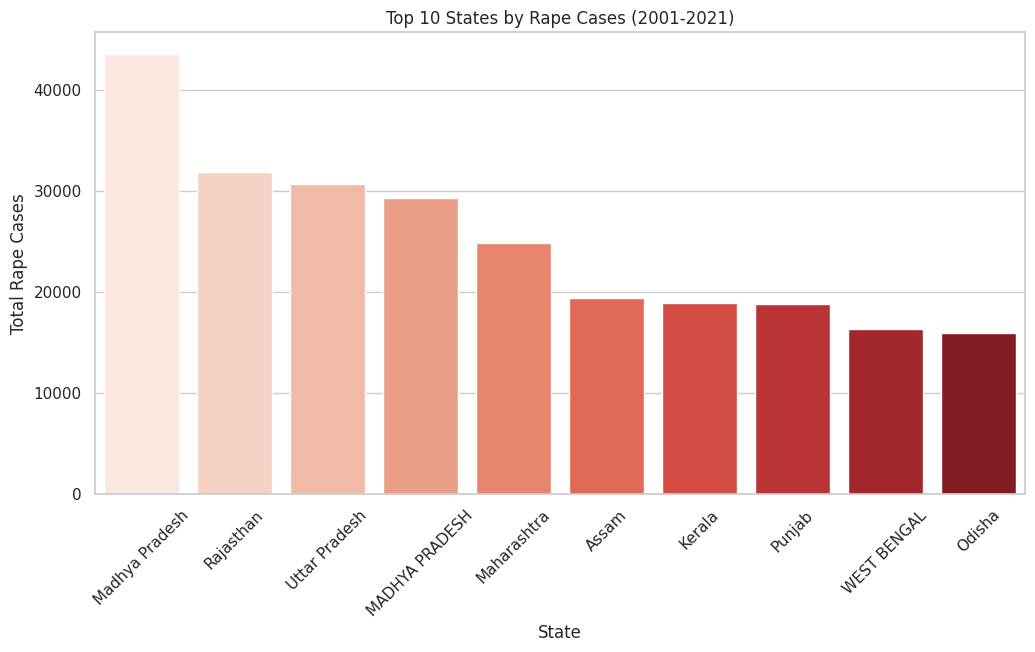

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Summarize data to find the top states for a specific crime type (e.g., Rape)
top_states_rape = crimes_data_cleaned.groupby('State')['Rape'].sum().sort_values(ascending=False).head(10)

# Plotting the top states by Rape cases
plt.figure(figsize=(12, 6))
sns.barplot(x=top_states_rape.index, y=top_states_rape.values, palette='Reds')
plt.title('Top 10 States by Rape Cases (2001-2021)')
plt.xlabel('State')
plt.ylabel('Total Rape Cases')
plt.xticks(rotation=45)
plt.show()

<Figure size 1400x800 with 0 Axes>

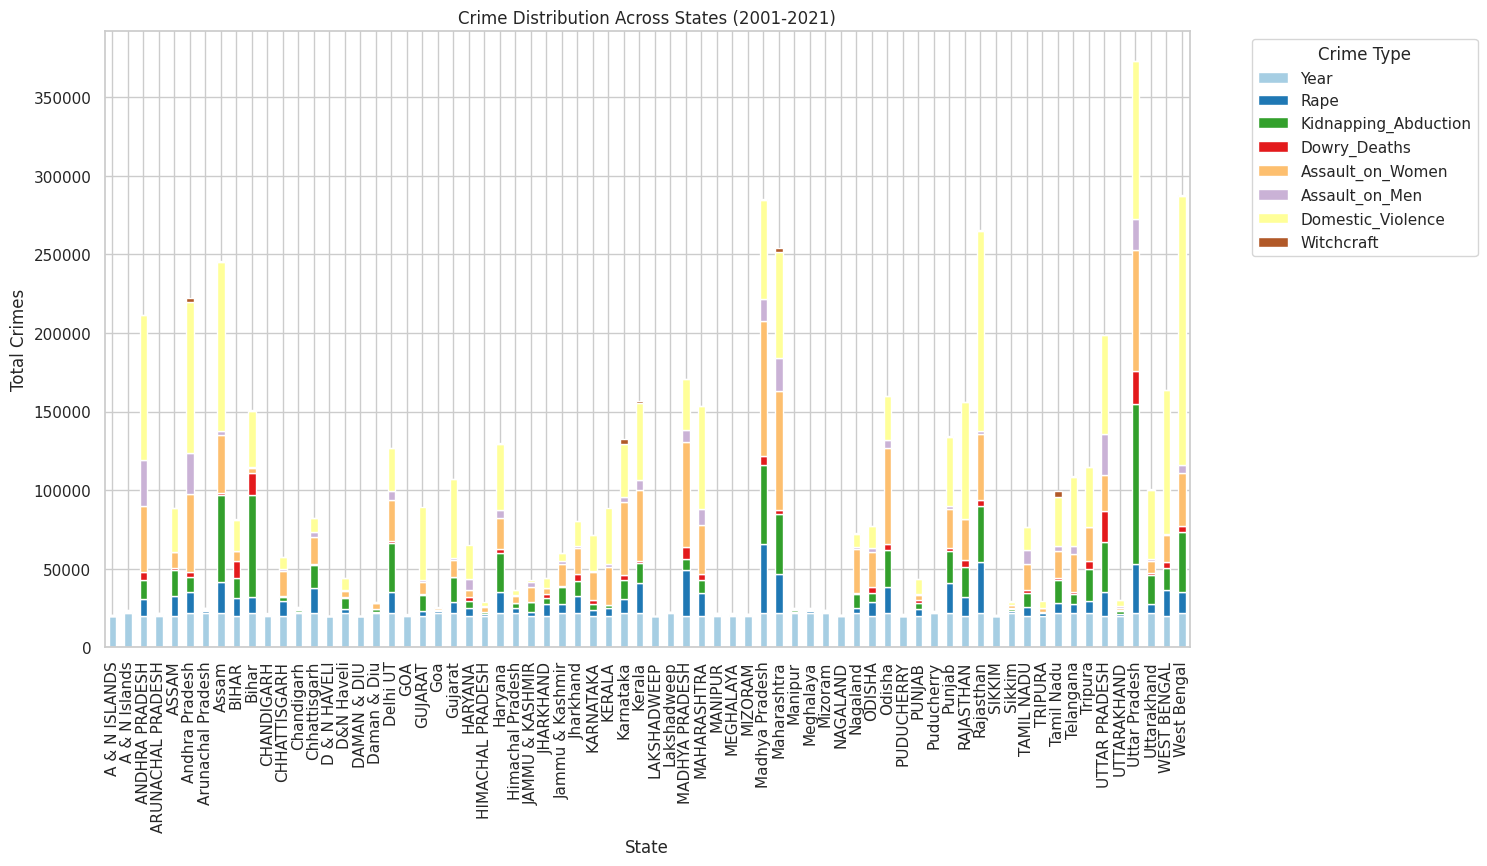

In [9]:
# Summarize the data by state and crime type
crime_distribution = crimes_data_cleaned.groupby('State').sum()

# Plotting a stacked bar plot
plt.figure(figsize=(14, 8))
crime_distribution.plot(kind='bar', stacked=True, colormap='Paired', figsize=(14, 8))
plt.title('Crime Distribution Across States (2001-2021)')
plt.xlabel('State')
plt.ylabel('Total Crimes')
plt.legend(title='Crime Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=90)
plt.show()

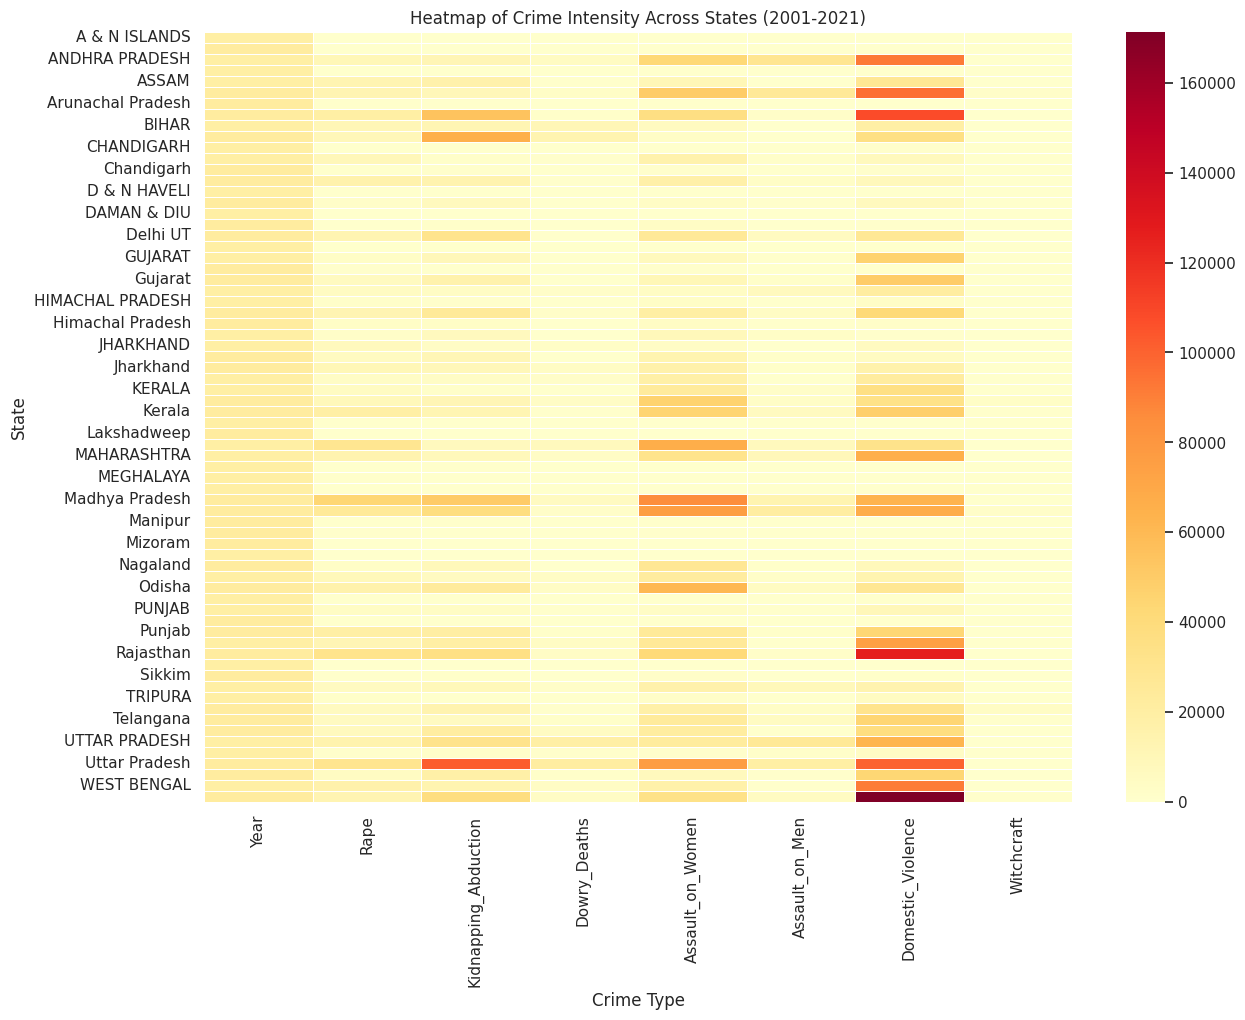

In [10]:
# Plotting a heatmap of crime intensity
plt.figure(figsize=(14, 10))
sns.heatmap(crime_distribution, cmap='YlOrRd', annot=False, linewidths=.5)
plt.title('Heatmap of Crime Intensity Across States (2001-2021)')
plt.xlabel('Crime Type')
plt.ylabel('State')
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


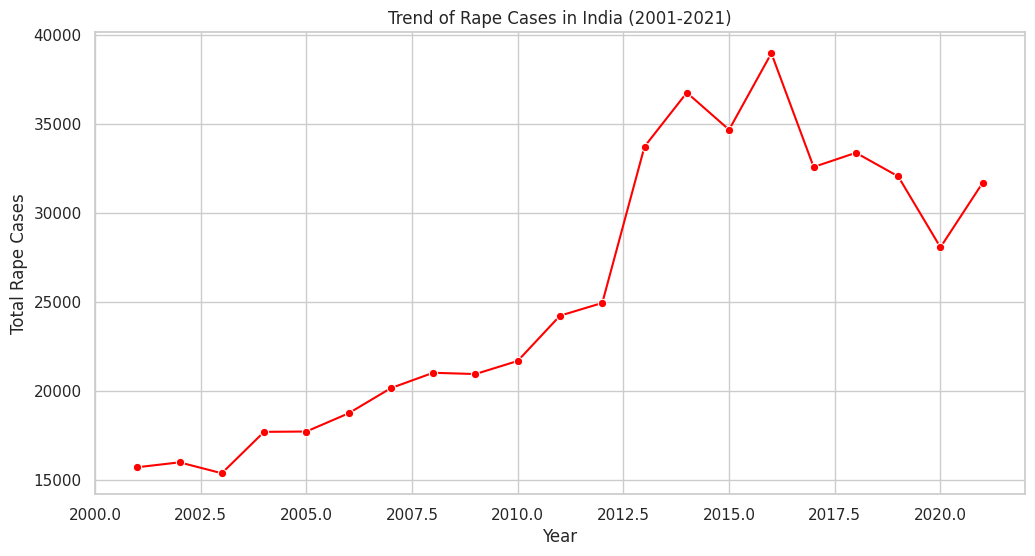

In [11]:
# Group data by Year and plot trends over time
yearly_trends = crimes_data_cleaned.groupby('Year').sum()

# Plotting the trend over time for a specific crime (e.g., Rape)
plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_trends, x=yearly_trends.index, y='Rape', marker='o', color='red')
plt.title('Trend of Rape Cases in India (2001-2021)')
plt.xlabel('Year')
plt.ylabel('Total Rape Cases')
plt.grid(True)
plt.show()

## Crimes Against Women in India (2001-2021): An Analysis

### Introduction
This project analyzes state-wise data on crimes committed against women in India from 2001 to 2021. The analysis covers various types of crimes, including rape, kidnapping and abduction, dowry deaths, and domestic violence.

### Methodology
The data was cleaned and preprocessed to remove unnecessary columns and standardize state names. Various visualizations, such as bar plots, heatmaps, and line plots, were used to explore the data and identify trends and patterns.

### Key Findings
- **Top States for Rape Cases:** Uttar Pradesh, Maharashtra, and Rajasthan reported the highest average number of rape cases.
- **Trends Over Time:** Rape cases have shown a steady increase from 2001 to 2021, with significant spikes in certain years.
- **Correlations:** There is a strong positive correlation between domestic violence and dowry deaths, suggesting that these crimes often occur together.

### Conclusion
The analysis highlights the persistent issue of crimes against women in India, with certain states and crime types showing alarming trends. Further research and policy intervention are necessary to address these issues.